In [3]:
import pandas as pd 

In [4]:
data =pd.read_csv("data.csv")

In [5]:
data

,hours,age,internet,marks
0,6.83,15,1,78.50
1,6.56,16,0,76.74
2,NaN,17,1,78.68
3,5.67,18,0,71.82
4,8.67,19,1,84.19
...,...,...,...,...
196,8.56,19,1,84.68
197,8.94,20,1,86.75
198,6.60,15,1,78.05
199,8.35,16,1,83.50


In [6]:
data.shape

(201, 4)

In [7]:
data.isnull().sum()

hours       5
age         0
internet    0
marks       0
dtype: int64

In [8]:
data['hours'] = pd.to_numeric(data['hours'], errors='coerce')


In [9]:
data['hours'].fillna(data['hours'].mean(), inplace=True)


C:\Users\anand\AppData\Local\Temp\ipykernel_30052\2800420807.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['hours'].fillna(data['hours'].mean(), inplace=True)


In [10]:
data.isnull().sum()

hours       0
age         0
internet    0
marks       0
dtype: int64

In [11]:
data.describe()

,hours,age,internet,marks
count,201.000000,201.000000,201.000000,201.000000
mean,30.276378,17.467662,0.552239,77.951244
std,321.902273,1.720523,0.498505,4.919626
min,4.150000,15.000000,0.000000,68.570000
25%,5.790000,16.000000,0.000000,73.400000
50%,7.190000,17.000000,1.000000,77.770000
75%,8.160000,19.000000,1.000000,82.300000
max,4571.000000,20.000000,1.000000,86.990000


In [12]:
num_cols = ['hours', 'age', 'marks']


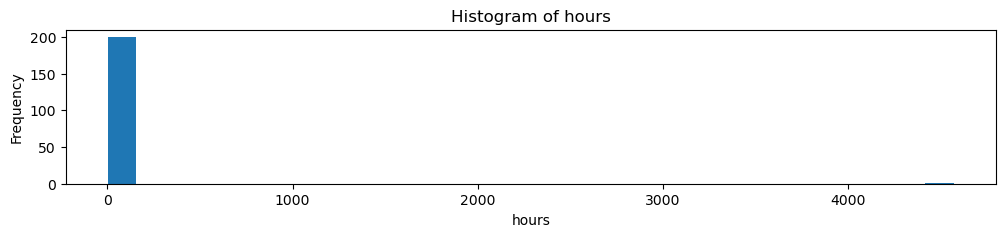

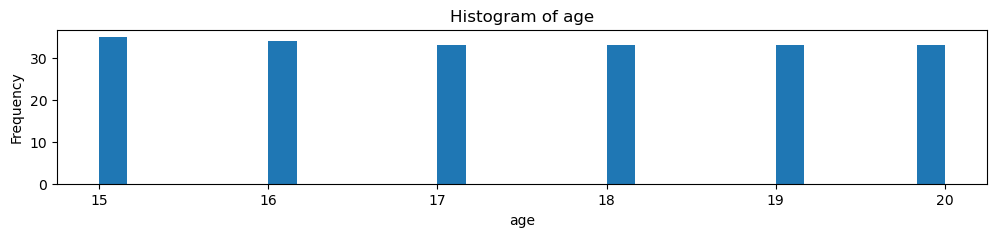

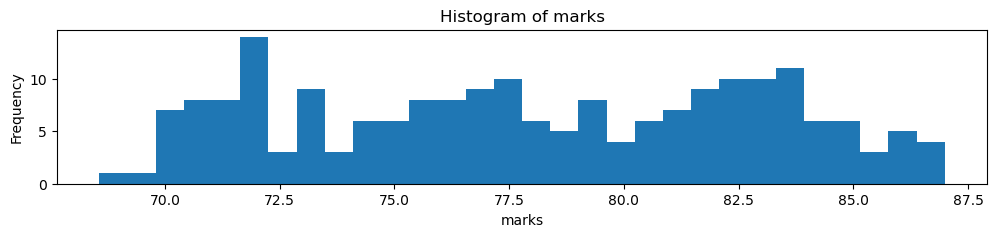

In [13]:
import matplotlib.pyplot as plt

for col in num_cols:
    plt.figure(figsize=(12, 2))
    plt.hist(data[col], bins=30)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()


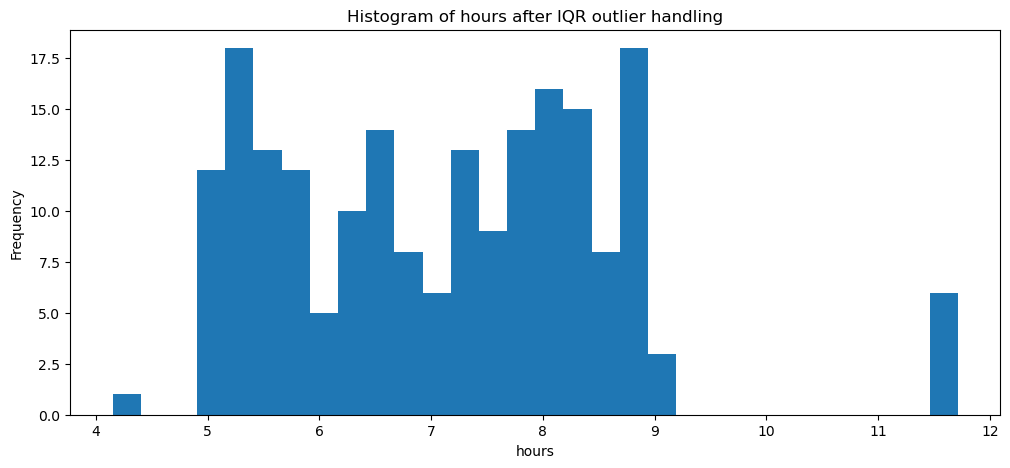

In [14]:
import matplotlib.pyplot as plt

col = 'hours'

# Q1, Q3, IQR
Q1 = data[col].quantile(0.25)
Q3 = data[col].quantile(0.75)
IQR = Q3 - Q1

# Limits
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

# IQR capping (recommended)
data[col] = data[col].clip(lower=lower_limit, upper=upper_limit)

# Confirm with histogram
plt.figure(figsize=(12,5))
plt.hist(data[col], bins=30)
plt.title('Histogram of hours after IQR outlier handling')
plt.xlabel('hours')
plt.ylabel('Frequency')
plt.show()


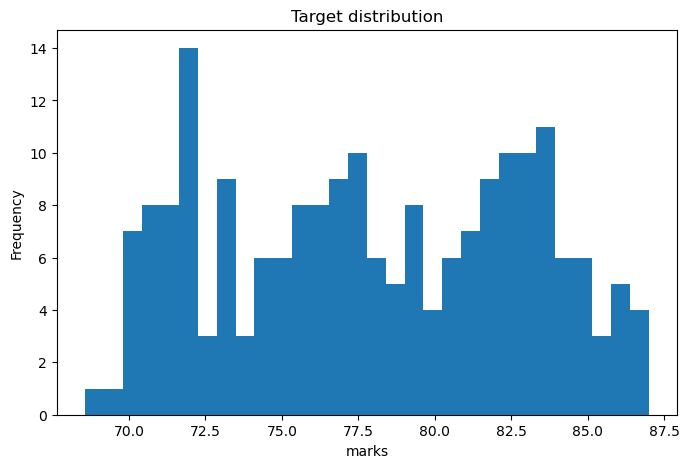

In [15]:
target = 'marks'

plt.figure(figsize=(8,5))
plt.hist(data[target], bins=30)
plt.title('Target distribution')
plt.xlabel(target)
plt.ylabel('Frequency')
plt.show()


In [16]:
import numpy as np

In [17]:
num_cols = data.select_dtypes(include=np.number).columns
num_cols = num_cols.drop(target)


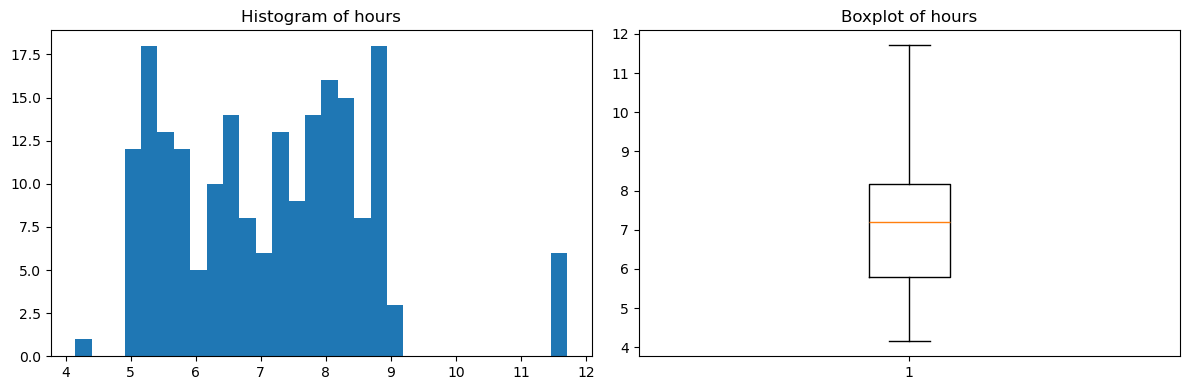

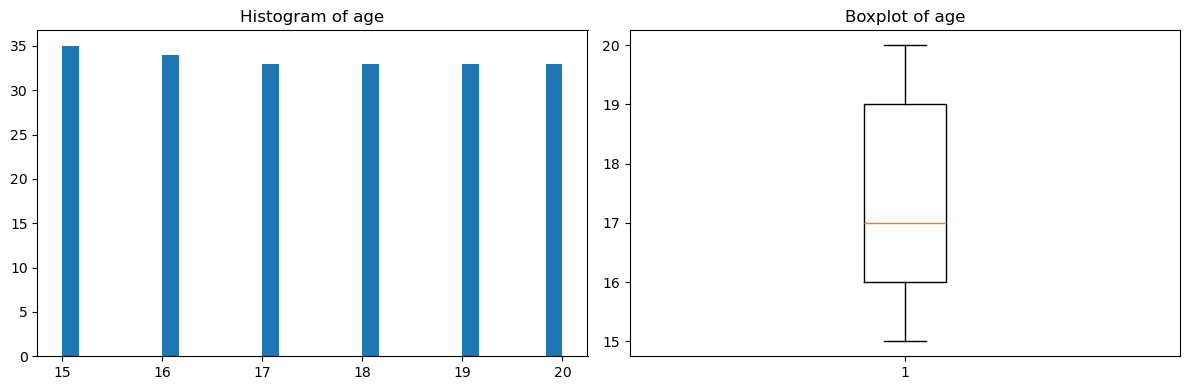

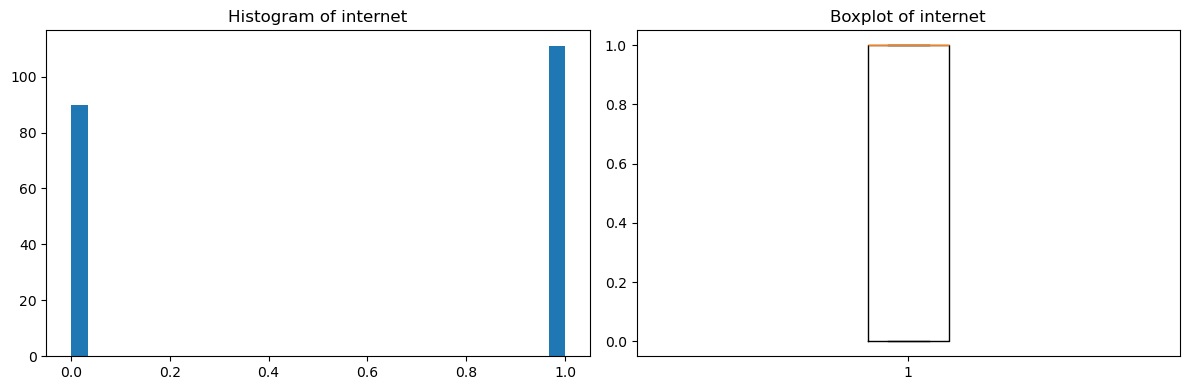

In [18]:
for col in num_cols:
    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    plt.hist(data[col], bins=30)
    plt.title(f'Histogram of {col}')

    plt.subplot(1,2,2)
    plt.boxplot(data[col])
    plt.title(f'Boxplot of {col}')

    plt.tight_layout()
    plt.show()


In [19]:
data[num_cols].skew()


hours       0.637261
age         0.022627
internet   -0.211688
dtype: float64

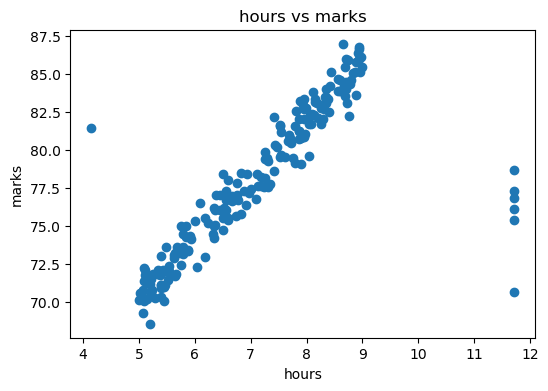

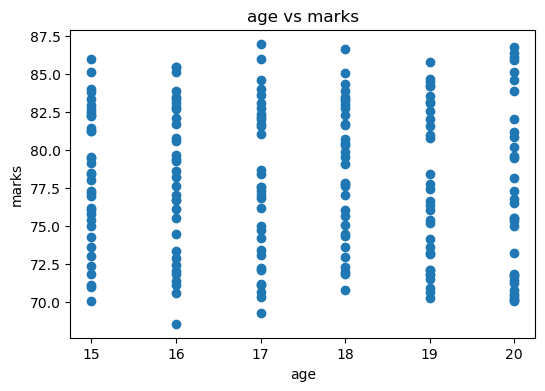

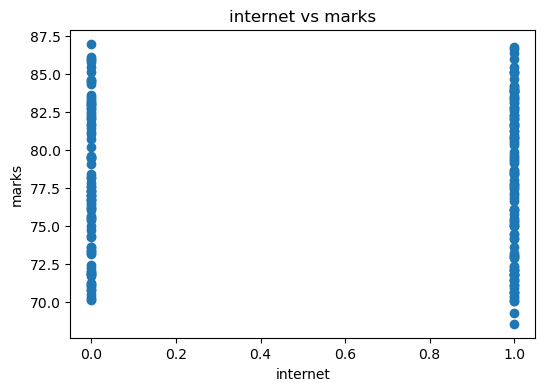

In [20]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    plt.scatter(data[col], data[target])
    plt.xlabel(col)
    plt.ylabel(target)
    plt.title(f'{col} vs {target}')
    plt.show()


In [21]:
col = 'hours'   # example

Q1 = data[col].quantile(0.25)
Q3 = data[col].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

data[col] = data[col].clip(lower, upper)


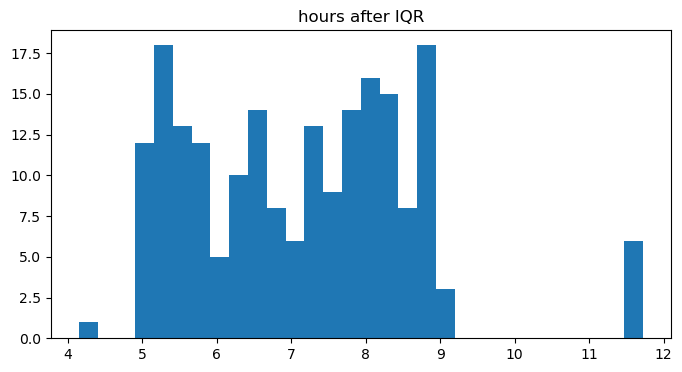

In [22]:
plt.figure(figsize=(8,4))
plt.hist(data[col], bins=30)
plt.title(f'{col} after IQR')
plt.show()


In [23]:
data.columns

Index(['hours', 'age', 'internet', 'marks'], dtype='object')

In [24]:
x=data[['hours', 'age', 'internet']]

In [25]:
y=data['marks']

In [26]:
from sklearn.model_selection import train_test_split

In [27]:
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.8)

In [28]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score

# =============================
# MODELS DICTIONARY
# =============================
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "KNN": KNeighborsRegressor(n_neighbors=5),
    "SVR": SVR()
}

# =============================
# TRAIN, PREDICT, EVALUATE
# =============================
results = {}

for name, model in models.items():
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    r2 = r2_score(y_test, y_pred)
    results[name] = r2
    print(f"{name} -> R2 Score: {r2:.4f}")

# =============================
# SORT RESULTS (BEST MODEL ON TOP)
# =============================
print("\nSorted by R2 Score:")
for k, v in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f"{k}: {v:.4f}")


Linear Regression -> R2 Score: -0.0866
Decision Tree -> R2 Score: 0.8479
Random Forest -> R2 Score: 0.8702
Gradient Boosting -> R2 Score: 0.8771
KNN -> R2 Score: 0.7544
SVR -> R2 Score: 0.2746

Sorted by R2 Score:
Gradient Boosting: 0.8771
Random Forest: 0.8702
Decision Tree: 0.8479
KNN: 0.7544
SVR: 0.2746
Linear Regression: -0.0866


In [41]:
model=GradientBoostingRegressor(random_state=42)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
r2 = r2_score(y_test, y_pred)
print(r2)


0.8770578471517201


In [42]:
print(model.score(x_train, y_train))
print(model.score(x_test, y_test))

0.9857482887191269
0.8770578471517201


In [43]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    model,          # your GradientBoostingRegressor
    x_train,
    y_train,
    cv=5,
    scoring='r2'
)

print("Cross-validation R2 scores:", cv_scores)
print("Mean CV R2:", cv_scores.mean())
print("Std CV R2:", cv_scores.std())


Cross-validation R2 scores: [0.94740497 0.93443    0.89217704 0.95935134 0.74981352]
Mean CV R2: 0.8966353739900252
Std CV R2: 0.07683204124788498


In [44]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor


In [45]:
param_grid = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [2, 3, 4]
}


In [46]:
gbr = GradientBoostingRegressor(random_state=42)

grid = GridSearchCV(
    estimator=gbr,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid.fit(x_train, y_train)


GridSearchCV(cv=5, estimator=GradientBoostingRegressor(random_state=42),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [2, 3, 4],
                         'n_estimators': [50, 100, 150]},
             scoring='r2')

In [35]:
print("Best Parameters:", grid.best_params_)
print("Best CV R2 Score:", grid.best_score_)


Best Parameters: {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 100}
Best CV R2 Score: 0.9090280207482373


In [47]:
best_model=grid.best_estimator_
best_model.fit(x_train, y_train)

y_pred = best_model.predict(x_test)

r2 = r2_score(y_test, y_pred)
print(r2)

0.8827039802182951


In [48]:
print(best_model.score(x_train, y_train))
print(best_model.score(x_test, y_test))

0.9713167689257018
0.8827039802182951


In [38]:
import pickle

In [50]:
filename= 'finalmodel_GradientBoostingRegressor.sav'
pickle.dump(best_model,open(filename,'wb'))
model=pickle.load(open('finalmodel_GradientBoostingRegressor.sav','rb'))
result=model.predict([[1,3,4]])
result

C:\Users\anand\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(


array([80.40612946])